# Business Problem

A hedge fund is seeking alternative asset classes to invest for its investors.  The hedge fund, which will remain anonymous, is already diversified across multiple asset classes - which includes equity, fixed incomes, real estate, and commodities.  The hedge fund has observed that retail and institutional investors have generated positive returns via cryptocurrency.  As a result, this hedge fund is requesting KBO Analytics to create a model that can predict Bitcoin prices in the future.

# Data Understanding

The data for examing the aforementioned problem comes from the following source: [Coin Codex](https://coincodex.com/crypto/bitcoin/historical-data/)

Before beginning to create any type of time series model, I want to examine and become familiar with the dataset. I will conduct exploratory data analysis in order to understand the dataset attributes, which includes, but not limited to the following:

1. Number of Columns
2. Number of Rows
3. Column Names
4. Format of the data in each column

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

from sklearn.metrics import mean_squared_error

import pmdarima as pm

In [2]:
# Reading File

bitcoin_df = pd.read_csv("data/bitcoin_2014_to_2026.csv")

In [3]:
# Examining the first 5 rows of the 'bitcoin_df' dataframe

bitcoin_df.head()

,Start,End,Open,High,Low,Close,Volume,Market Cap
0,2026-06-01,2026-06-02,73868.59,73986.02,70893.96,71439.79,3.773704e+10,1.450453e+12
1,2026-05-31,2026-06-01,73876.30,74271.63,73432.95,73688.05,2.145341e+10,1.480082e+12
2,2026-05-30,2026-05-31,73450.12,74080.02,73238.96,73867.98,3.748501e+10,1.477494e+12
3,2026-05-29,2026-05-30,73669.36,74323.98,72639.16,73476.46,4.408717e+10,1.474262e+12
4,2026-05-28,2026-05-29,74545.09,74573.73,72762.76,73553.92,5.189816e+10,1.472486e+12


In [4]:
# Examining the last 5 rows of the 'bitcoin_df' dataframe

bitcoin_df.tail()

,Start,End,Open,High,Low,Close,Volume,Market Cap
4526,2014-01-09,2014-01-10,841.47,864.36,804.14,846.86,5.177652e+07,1.030407e+10
4527,2014-01-08,2014-01-09,795.99,870.68,776.18,842.72,9.721611e+07,1.019892e+10
4528,2014-01-07,2014-01-08,946.49,965.74,802.00,802.00,7.558311e+07,1.104477e+10
4529,2014-01-06,2014-01-07,936.05,1017.12,905.71,953.29,8.422901e+07,1.174604e+10
4530,2014-01-05,2014-01-06,858.55,952.40,854.52,933.53,5.139392e+07,1.087804e+10


In [5]:
# Examining the shape of the 'bitcoin_df' dataframe

bitcoin_df.shape

(4531, 8)

In [6]:
# Examining the 'bitcoin_df' dataframe

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 0 to 4530
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Start       4531 non-null   object 
 1   End         4531 non-null   object 
 2   Open        4531 non-null   float64
 3   High        4531 non-null   float64
 4   Low         4531 non-null   float64
 5   Close       4531 non-null   float64
 6   Volume      4531 non-null   float64
 7   Market Cap  4531 non-null   float64
dtypes: float64(6), object(2)
memory usage: 283.3+ KB


In [7]:
# Obtaining descriptive analytics of the 'bitcoin_df' dataframe

bitcoin_df.describe()

,Open,High,Low,Close,Volume,Market Cap
count,4531.000000,4531.000000,4531.000000,4531.000000,4.531000e+03,4.531000e+03
mean,27003.688488,27526.497384,26456.890629,27021.663436,3.521488e+10,5.232794e+11
std,32160.258870,32680.823086,31612.563903,32168.110924,3.886304e+10,6.392699e+11
min,178.103000,211.731000,171.510000,178.795000,2.688736e+06,2.690697e+09
25%,1012.590000,1043.855000,991.586500,1016.730000,2.049405e+08,1.651487e+10
50%,10300.390061,10474.365680,10008.252865,10313.443526,2.374011e+10,1.832743e+11
75%,43288.930000,44145.078950,42490.183960,43326.830000,5.926236e+10,8.370000e+11
max,124696.000000,126025.000000,123164.000000,124735.000000,2.121958e+11,2.479741e+12


In [8]:
# Examining whether or not there is missing data

bitcoin_df.isna().sum()

Start         0
End           0
Open          0
High          0
Low           0
Close         0
Volume        0
Market Cap    0
dtype: int64

In [9]:
# Examining whether or not there are duplicates

bitcoin_df.duplicated().sum()

0

# Data Preparation

I have completed my exploratory data analysis (EDA).  Based on the analytics, the dataset contains a total of 4,531 rows.  There are a total of 8 columns, which are the following:

- *Start* - Start Date
- *End* - End Date
- *Open* - Opening (Bitcoin) Price (for the day)
- *High* - Highest (Bitcoin) Price (for the day)
- *Low* - Lowest (Bitcoin) Price (for the day)
- *Close* - Closing (Bitcoin) Price (for the day)
- *Volume* - 24-hour (Bitcoin) trading volume (for the day)
- *Market Cap* - Market capitalization (of Bitcoin) for the day

I will use the Start Date and Closing Price to create the time series models.  As a result, I will remove the following columns: *End*, *Open*, *High*, *Low*, *Volume*, and *Market Cap*.

I also noticed that the first row of data pertains to a Start Date and End Date of January 1st, 2026; and January 2nd, 2026, respectively.  The last row of data pertains to a Start Date and End Date of January 5th, 2014; and January 6th, 2014.  I will need to invert the row order of the dataset before proceeding to the modeling stage.

The *Start* column is in a string format.  I want to convert the aforementioned column to a date format since the column is capturing time.

Finally, I will relabel the columns.  I will rename the *Start* column to *Date*.  I will also rename the *Close* column to *Price*.

In [10]:
# Removing the 'End', 'Open', 'High', 'Low', 'Volume', 'Market Cap' columns from the dataset

bitcoin_df.drop(columns=['End', 'Open', 'High', 'Low', 'Volume', 'Market Cap'], inplace=True)

In [11]:
# Checking whether or not the columns - 'End', 'Open', 'High', 'Low', 'Volume', 'Market Cap' - have been removed

bitcoin_df.head()

,Start,Close
0,2026-06-01,71439.79
1,2026-05-31,73688.05
2,2026-05-30,73867.98
3,2026-05-29,73476.46
4,2026-05-28,73553.92


In [12]:
# Inverting the row order of the dataset

bitcoin_df = bitcoin_df.iloc[::-1]

In [13]:
# Checking whether or not the row order of the dataset has been inverted

bitcoin_df.head(20)

,Start,Close
4530,2014-01-05,933.53
4529,2014-01-06,953.29
4528,2014-01-07,802.00
4527,2014-01-08,842.72
4526,2014-01-09,846.86
4525,2014-01-10,868.48
4524,2014-01-11,913.95
4523,2014-01-12,863.22
4522,2014-01-13,841.20
4521,2014-01-14,833.27


In [14]:
# Another check to determine whether or not the row order of the dataset has been inverted

bitcoin_df.tail(20)

,Start,Close
19,2026-05-13,79295.40
18,2026-05-14,81068.75
17,2026-05-15,79114.03
16,2026-05-16,78153.69
15,2026-05-17,77449.99
14,2026-05-18,76969.33
13,2026-05-19,76845.56
12,2026-05-20,77538.40
11,2026-05-21,77696.07
10,2026-05-22,75561.40


In [15]:
# Converting the 'Start' column to time format

bitcoin_df['Start'] = pd.to_datetime(bitcoin_df['Start'])

In [16]:
# Checking whether or not the format of the 'Start' column has been converted to time format

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 4530 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Start   4531 non-null   datetime64[ns]
 1   Close   4531 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 70.9 KB


In [17]:
# Relabeling the 'Start' column to 'Date

bitcoin_df.rename(columns = {'Start':'Date'}, inplace=True)

In [18]:
# Checking whether or not the 'Start' column has been renamed to 'Date'

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 4530 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4531 non-null   datetime64[ns]
 1   Close   4531 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 70.9 KB


In [19]:
# Relabeling the 'Close' column to 'Price'

bitcoin_df.rename(columns = {'Close':'Price'}, inplace=True)

In [20]:
# Checking whether or not the 'Close' columns has been renamed to 'Price'

bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 4530 to 0
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4531 non-null   datetime64[ns]
 1   Price   4531 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 70.9 KB


# Modeling

The data preparation state is complete.  I will transition towards the modeling stage.  To be specific, I will create a series of four time series models, and select the best one to predict Bitcoin prices in the future.  The four categoeis of times series models are the following:


**1. Naive Forecast**  This time series model uses the previous data points to predict the next data points.  The Naive forecast serves as a baseline model of comparison for other time series models.

**2. Moving Average**  This time series model is based on past forecast errors instead of the past data points.  The forecast errors can be referred to as residuals or *shocks*.  Within time series modeling, the forecast errors last for a finite error of steps and eventually disappear.  The objective of creating a moving average time series model is to create another baseline model of comparison.

**3. ARIMA**  The ARIMA Model is more complex than the Naive Forecast and Moving Average Models.  There are three variables that make up the ARIMA model, which are the following:

- Auto Regressive (AR) (denoted as *p*) - in the same manner as the Naive Forecast, this variable references the number of lagged data points to forecast future data points.  As an example, if one lagged data point is utilized in the forecast, then *p* is equal to 1.


- Stationarity (I) (denoted as *d*) - this references the amount of differencing required to remove non-stationary trends.  In order to successfully create an ARIMA model, the data needs to be stationary.  In other words, the data needs to have a constant average, constant variance (the spread between the actual data point and forecasted data point remains constant), and constant autocorrelation (the relationship between past observations and current observations only depends on time).  Differencing is the actual transformation that turns non-stationary data into stationary data.


- Moving Average (MA) (denoted as *q*) - this is the same Moving Average as highlighted in the aforementioned Moving Average Model section.

In summary, I will manually attempt to create an ARIMA model based on the following three values:

- *p*: Trend Autoregression Order
- *d*: Trend Difference Order
- *q*: Trend Moving Average Order

**4. Auto-ARIMA** I will create another set of time series models based on the Auto-ARIMA function within the Statsmodel library. 

## Naive Forecast ##

### Naive Forecast ###

In [21]:
# Creating a copy of the 'bitcoin_df' dataframe

bitcoin_df_naive = bitcoin_df.copy()

In [22]:
# Checking to determine whether or not the 'bitcoin_df_naive' dataframe has been created

bitcoin_df_naive.head()

,Date,Price
4530,2014-01-05,933.53
4529,2014-01-06,953.29
4528,2014-01-07,802.00
4527,2014-01-08,842.72
4526,2014-01-09,846.86


In [23]:
# Creating a new column 'Price_Lag'

bitcoin_df_naive['Price_Lag'] = bitcoin_df_naive['Price'].shift(1)

In [24]:
# Examining the new column 'Price_Lag'

bitcoin_df_naive.head()

,Date,Price,Price_Lag
4530,2014-01-05,933.53,NaN
4529,2014-01-06,953.29,933.53
4528,2014-01-07,802.00,953.29
4527,2014-01-08,842.72,802.00
4526,2014-01-09,846.86,842.72


In [25]:
# Creating the train and test set from the 'bitcoin_df_naive' dataframe

# The last 360 data points are going to be the test set

new_train_naive, new_test_naive = bitcoin_df_naive[1:bitcoin_df_naive.shape[0]-360], bitcoin_df_naive[bitcoin_df_naive.shape[0]-360:]

In [26]:
# Examining the train set

new_train_naive.head()

,Date,Price,Price_Lag
4529,2014-01-06,953.29,933.53
4528,2014-01-07,802.00,953.29
4527,2014-01-08,842.72,802.00
4526,2014-01-09,846.86,842.72
4525,2014-01-10,868.48,846.86


In [27]:
# Examining the test set

new_test_naive.head()

,Date,Price,Price_Lag
359,2025-06-07,105603.0,104302.0
358,2025-06-08,105661.0,105603.0
357,2025-06-09,110193.0,105661.0
356,2025-06-10,110229.0,110193.0
355,2025-06-11,108682.0,110229.0


In [28]:
# Creating the X-train and y-train for the train set

X_train_naive, y_train_naive = new_train_naive['Price_Lag'], new_train_naive['Price']

In [29]:
# Creating the X-test and y-test from the test set

X_test_naive, y_test_naive = new_test_naive['Price_Lag'], new_test_naive['Price']

In [30]:
# Examining the 'X_test' set

X_test_naive.head()

359    104302.0
358    105603.0
357    105661.0
356    110193.0
355    110229.0
Name: Price_Lag, dtype: float64

In [31]:
# Examining the 'y_test' set

y_test_naive.head()

359    105603.0
358    105661.0
357    110193.0
356    110229.0
355    108682.0
Name: Price, dtype: float64

In [32]:
# Calculate Root Mean Square Error (RMSE) of the Naive Forecast Model

rmse_naive = mean_squared_error(y_test_naive, X_test_naive, squared=False)

rmse_naive

1950.8802887530742

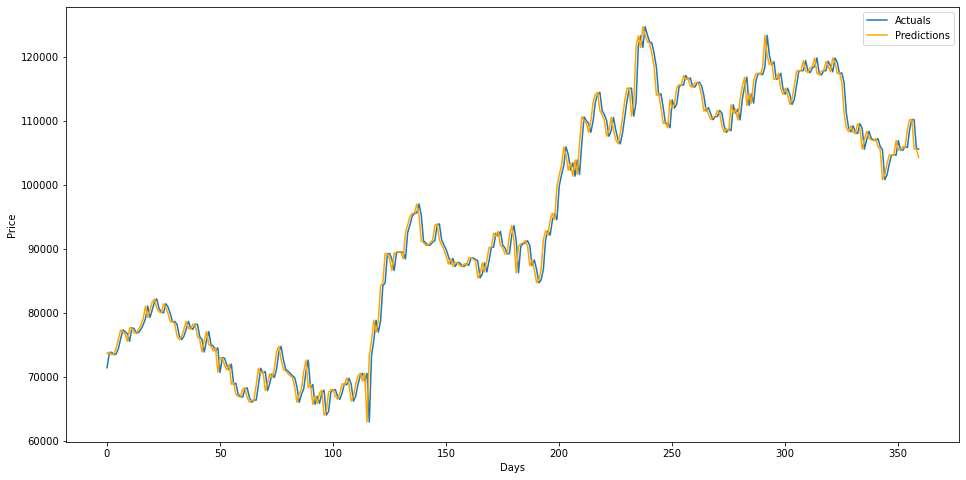

In [57]:
# Plotting the predictions, or 'X_test_naive', against the actual results, or 'y_test_naive'

plt.figure(figsize=(16,8)) # Width, Height in Inches

plt.plot(y_test_naive, label='Actuals')
plt.plot(X_test_naive, color='orange', label='Predictions')

plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

### Naive Forecast (with Log Transformation) ###

In [33]:
# Creating another copy of the 'bitcoin_df' dataframe

bitcoin_df_naive_log = bitcoin_df.copy()

In [34]:
# Checking to determine whether or not the 'bitcoin_df_naive_log' dataframe has been created

bitcoin_df_naive_log.head()

,Date,Price
4530,2014-01-05,933.53
4529,2014-01-06,953.29
4528,2014-01-07,802.00
4527,2014-01-08,842.72
4526,2014-01-09,846.86


In [35]:
# Applying Log Transformation to the 'Price' column

bitcoin_df_naive_log['Price'] = np.log(bitcoin_df_naive_log['Price'])

In [36]:
# Checking whether or not the Log Transformation has been applied to the 'Price' column

bitcoin_df_naive_log.head()

,Date,Price
4530,2014-01-05,6.838973
4529,2014-01-06,6.859919
4528,2014-01-07,6.687109
4527,2014-01-08,6.736635
4526,2014-01-09,6.741535


In [37]:
# Creating a new column 'Price_Previous'

bitcoin_df_naive_log['Price_Previous'] = bitcoin_df_naive_log['Price'].shift(1)

In [38]:
# Examining the new column 'Price_Previous'

bitcoin_df_naive_log.head()

,Date,Price,Price_Previous
4530,2014-01-05,6.838973,NaN
4529,2014-01-06,6.859919,6.838973
4528,2014-01-07,6.687109,6.859919
4527,2014-01-08,6.736635,6.687109
4526,2014-01-09,6.741535,6.736635


In [39]:
# Creating the train and test set from the 'bitcoin_df_naive_log' dataframe

# The last 360 data points are going to be the test set

new_train_naive_log, new_test_naive_log = bitcoin_df_naive_log[1:bitcoin_df_naive_log.shape[0]-360], bitcoin_df_naive_log[bitcoin_df_naive_log.shape[0]-360:]

In [40]:
# Examining the train set

new_train_naive_log.head()

,Date,Price,Price_Previous
4529,2014-01-06,6.859919,6.838973
4528,2014-01-07,6.687109,6.859919
4527,2014-01-08,6.736635,6.687109
4526,2014-01-09,6.741535,6.736635
4525,2014-01-10,6.766745,6.741535


In [41]:
# Examining the test set

new_test_naive_log.head()

,Date,Price,Price_Previous
359,2025-06-07,11.567442,11.555046
358,2025-06-08,11.567991,11.567442
357,2025-06-09,11.609989,11.567991
356,2025-06-10,11.610315,11.609989
355,2025-06-11,11.596181,11.610315


In [42]:
# Creating the X-train and y-train for the train set

X_train_naive_log, y_train_naive_log = new_train_naive_log['Price_Previous'], new_train_naive_log['Price']

In [43]:
# Creating the X-test and y-test from the test set

X_test_naive_log, y_test_naive_log = new_test_naive_log['Price_Previous'], new_test_naive_log['Price']

In [44]:
# Examining the 'X_test' set

X_test_naive_log.head()

359    11.555046
358    11.567442
357    11.567991
356    11.609989
355    11.610315
Name: Price_Previous, dtype: float64

In [45]:
# Examining the 'y_test' set

y_test_naive.head()

359    105603.0
358    105661.0
357    110193.0
356    110229.0
355    108682.0
Name: Price, dtype: float64

In [46]:
# Calculate Root Mean Square Error (RMSE) of the Naive Forecast Model with Log Transformation

rmse_naive_log = mean_squared_error(y_test_naive_log, X_test_naive_log, squared=False)

rmse_naive_log

0.022194514861663052

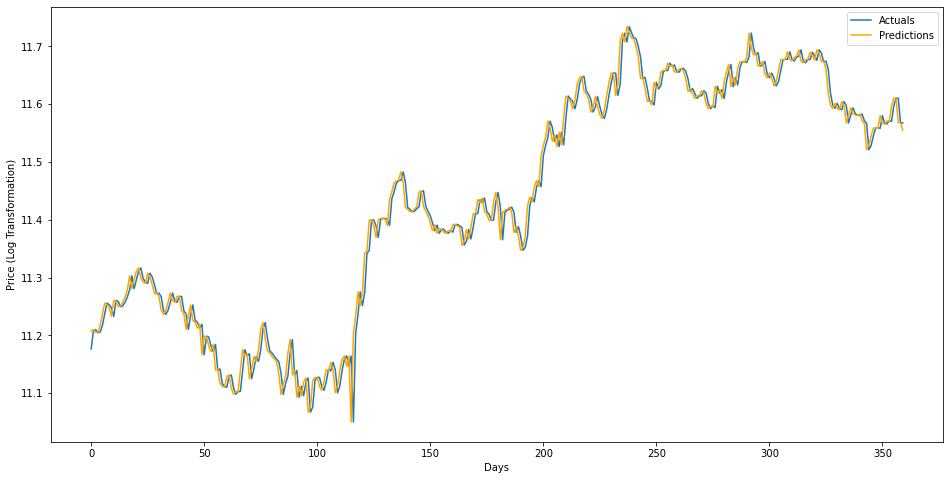

In [58]:
# Plotting the predictions, or 'X_test_naive_log', against the actual results, or 'y_test_naive_log'

plt.figure(figsize=(16,8)) # Width, Height in Inches

plt.plot(y_test_naive_log, label='Actuals')
plt.plot(X_test_naive_log, color='orange', label='Predictions')

plt.xlabel("Days")
plt.ylabel("Price (Log Transformation)")
plt.legend()
plt.show()

## Moving Average ##

## ARIMA ##

## Auto-ARIMA ##

# Overall Conclusion and Recommendations

## Overall Conclusion and Recommendations

## Next Steps